# Classificação de Comentários

Lucas de Oliveira Ferreira

# Explicação



O objetivo desse trabalho é fornecer uma tabela com a classificação dos comentários propostos, mas mais do que isso explorar como diferentes métodos e conjunto de dados performam nesse problema.

Para análise de performance eu fiz uma classificação manual dos 50 comentários que será usada como base.

As sessões terão explicações no seu início para que não seja necessário revisar todo o código que possui muitas partes repetitivas, mas isso fica a critério do leitor.

# Downloads

Com exceção do arquivo de comentários fornecido, os outros arquivos baixados são citados na sessão referências.

In [ ]:
# comments

!gdown 1m8oN7jBKsJyczgTezWPUCPMIIEA921nW

Downloading...
From: https://drive.google.com/uc?id=1m8oN7jBKsJyczgTezWPUCPMIIEA921nW
To: /content/comentarios.txt
100% 953/953 [00:00<00:00, 3.85MB/s]


In [ ]:
# OpLexicon

!gdown 19r3e1SaxlgFfuSQz8oKeBGiBIFOPi1cU

Downloading...
From: https://drive.google.com/uc?id=19r3e1SaxlgFfuSQz8oKeBGiBIFOPi1cU
To: /content/OpLexicon.csv
100% 418k/418k [00:00<00:00, 44.6MB/s]


In [ ]:
# Reviews Play Store

!gdown 1fWRZCmYykRWRE_i23XfIq1_kwE9mn2Kd

Downloading...
From: https://drive.google.com/uc?id=1fWRZCmYykRWRE_i23XfIq1_kwE9mn2Kd
To: /content/ReviewsPlayStore.csv
100% 701k/701k [00:00<00:00, 101MB/s]


In [ ]:
# Reviews Mercado Livre

!gdown 1KDh76k3Z1pFuathNO1qV-VPcTwuULNQh
!gdown 1AvGMpmyO5Btq1KUQoMdxmJ1wmab2X9wP

Downloading...
From: https://drive.google.com/uc?id=1KDh76k3Z1pFuathNO1qV-VPcTwuULNQh
To: /content/reviews_mercadolivre_com_br_1.json
100% 26.3M/26.3M [00:00<00:00, 80.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1AvGMpmyO5Btq1KUQoMdxmJ1wmab2X9wP
To: /content/reviews_mercadolivre_com_br_2.json
100% 26.1M/26.1M [00:00<00:00, 40.9MB/s]


In [ ]:
# Reviews Livros

!gdown 1S07x4WkraLuegwbEeQR9csjhjkzsKp1l
!gdown 1Oy3UqcYOQEBgA6AURuxkQxI7-BcmGoAY

Downloading...
From: https://drive.google.com/uc?id=1S07x4WkraLuegwbEeQR9csjhjkzsKp1l
To: /content/livros_train.csv
100% 1.64M/1.64M [00:00<00:00, 123MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Oy3UqcYOQEBgA6AURuxkQxI7-BcmGoAY
To: /content/livros_test.csv
100% 588k/588k [00:00<00:00, 36.6MB/s]


In [ ]:
# B2W

!wget https://raw.githubusercontent.com/HenriqueVarellaEhrenfried/B2W-Datasets/main/Dataset.zip
!unzip Dataset.zip


Streaming output truncated to the last 5000 lines.
  inflating: Dataset/B2W-Recommend-Balanced/1_33456.txt  
  inflating: Dataset/B2W-Recommend-Balanced/1_20169.txt  
  inflating: Dataset/B2W-Recommend-Balanced/1_17078.txt  
  inflating: Dataset/B2W-Recommend-Balanced/1_29947.txt  
  inflating: Dataset/B2W-Recommend-Balanced/1_17264.txt  
  inflating: Dataset/B2W-Recommend-Balanced/0_26056.txt  
  inflating: Dataset/B2W-Recommend-Balanced/1_30968.txt  
  inflating: Dataset/B2W-Recommend-Balanced/1_25289.txt  
  inflating: Dataset/B2W-Recommend-Balanced/1_17752.txt  
 extracting: Dataset/B2W-Recommend-Balanced/0_17789.txt  
  inflating: Dataset/B2W-Recommend-Balanced/0_7898.txt  
  inflating: Dataset/B2W-Recommend-Balanced/0_13603.txt  
  inflating: Dataset/B2W-Recommend-Balanced/1_28983.txt  
  inflating: Dataset/B2W-Recommend-Balanced/1_16181.txt  
  inflating: Dataset/B2W-Recommend-Balanced/1_34107.txt  
  inflating: Dataset/B2W-Recommend-Balanced/1_20545.txt  
  inflating: Dataset/B

In [ ]:
!mv Dataset/B2W-Polarity-Balanced Dataset_tmp
!rm -rf Dataset
!mkdir Dataset
!mv Dataset_tmp Dataset/B2W-Polarity-Balanced
!rm Dataset.zip


In [ ]:
!pip install gensim

In [ ]:

!pip install -q transformers torch


In [ ]:
!pip install -U sentence-transformers


In [ ]:
!pip install umap-learn


# Imports

In [ ]:
import re
import os
import nltk
import unicodedata
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from nltk.tokenize import word_tokenize

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import torch
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW

from sentence_transformers import SentenceTransformer
import umap

from gensim.models import Word2Vec

# Ferramentas

## Normalização

Defini funções para normalizar palavras, remover palavras que não agregam sentimentos, um stemmer e uma função bem simples para colocar palavras no singular.

In [ ]:
# Downloads necessários
nltk.download('stopwords')
nltk.download('rslp')

stopwords_pt = set(stopwords.words('portuguese'))
stemmer = RSLPStemmer()

PALAVRAS_REMOVER = {
    "e", "ou", "mas",
    "o", "a", "os", "as",
    "um", "uma", "uns", "umas",
    "de", "do", "da", "dos", "das",
    "em", "no", "na", "nos", "nas",
    "por", "para", "com",
}

def normalizar_frase(frase: str) -> str:
    # 1. lowercase
    frase = frase.lower()

    # 2. remover pontuação e números (mantendo acentos)
    frase = re.sub(r'[^a-záàâãéêíóôõúç\s]', ' ', frase)

    # 3. tokenização
    tokens = frase.split()

    # 4. remover apenas palavras específicas
    tokens_norm = [
        token
        for token in tokens
        if token not in PALAVRAS_REMOVER
        and len(token) > 1
    ]

    return ' '.join(tokens_norm)

def normalizar_frase_stem(frase: str) -> str:
    # 1. lowercase
    frase = frase.lower()

    # 2. remover pontuação e números (mantendo acentos)
    frase = re.sub(r'[^a-záàâãéêíóôõúç\s]', ' ', frase)

    # 3. tokenização
    tokens = frase.split()

    # 4. remover apenas palavras específicas
    tokens_norm = [
        stemmer.stem(token)
        for token in tokens
        if token not in PALAVRAS_REMOVER
        and len(token) > 1
    ]

    return ' '.join(tokens_norm)

def stem_word(word: str) -> str:
    return stemmer.stem(word)

def normalize_word(word: str) -> str:
    # lowercase
    word = word.lower()

    # remove accents
    word = unicodedata.normalize("NFKD", word)
    word = "".join(c for c in word if not unicodedata.combining(c))

    # keep only letters and numbers
    word = re.sub(r"[^a-z0-9]", "", word)

    # plural normalization (PT-BR heurístico)
    if len(word) > 3:
        if word.endswith("oes") or word.endswith("aes"):
            word = word[:-3] + "ao"
        elif word.endswith("eis"):
            word = word[:-2] + "il"
        elif word.endswith("ns"):
            word = word[:-2] + "m"
        elif word.endswith("es"):
            word = word[:-2]
        elif word.endswith("is"):
            word = word
        elif word.endswith("s"):
            word = word[:-1]

    return word


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


In [ ]:
frase = """
App Shopee razões apesar fácil utilização apresenta alguns bugs.
Exemplo: sugestão palavras erradas campo pesquisa acarretando
buscas erradas, sugestão produtos que têm nada a ver.
Coisas interface, dificuldade acesso, algum jogo trava,
durante algum jogo falha carregamento, certos anexos,
avaliação produto geral problemática, pode contornar
pois ocorre tanto frequentemente.
"""

print(normalizar_frase(frase))


app shopee razões apesar fácil utilização apresenta alguns bugs exemplo sugestão palavras erradas campo pesquisa acarretando buscas erradas sugestão produtos que têm nada ver coisas interface dificuldade acesso algum jogo trava durante algum jogo falha carregamento certos anexos avaliação produto geral problemática pode contornar pois ocorre tanto frequentemente


In [ ]:
frase = """
problemas
"""

print(normalize_word(frase))

problema


# Construindo Datasets

Explicação de cada Dataset:

- Comentários: são os 50 comentários fornecidos, a eles eu adiciono os rótulos que eu adicionei manualmente e rótulos previstos pelo gpt que eu só usei para checar o quão parecido eram com os meus.
- Play Store: dados de reviews da play store, pré-processados com normalização dos textos, mapeamento de classes e remoção de nulos, recuperados da fonte: https://zenodo.org/records/10823148.
- Mercado Livre: dados de reviews do mercado livre, pré-processados com normalização dos textos e mapeamento de classes, recuperados da fonte: https://github.com/octaprice/ecommerce-product-dataset/tree/main/data/mercadolivre_com_br.
- Livros: dados de reviews de livros, pré-processados  com normalização dos textos e mapeamento de classes, recuperados da fonte: https://github.com/ruanchaves/reli.
- B2W: dados da plataforma B2W, já pré-processados de forma a terem rótulos balanceados recuperados da fonte: https://github.com/HenriqueVarellaEhrenfried/B2W-Datasets/blob/main/Dataset.zip.

## Dataset de Comentários

In [ ]:
with open('comentarios.txt', 'r') as f:
    comments = re.findall(r'"([^"]*)"', f.read())

In [ ]:
print(comments)

['muito bom, gostei bastante', 'funciona bem', 'mais ou menos', 'nao gostei', 'app excelente', 'demora pra carregar', 'ok, nada demais', 'odiei a experiencia', 'bom, mas podia melhorar', 'pessimo atendimento', 'gostei do design', 'trava as vezes', 'cumpre o que promete', 'nao e ruim', 'muito lento', 'adorei o app', 'experiencia razoavel', 'horrivel, nao recomendo', 'bom demais', 'deixa a desejar', 'top demais', 'funciona quando quer', 'excelente servico', 'nada a reclamar', 'interface confusa', 'nao funciona direito', 'legalzinho', 'bem ruim', 'app ok', 'muito bom mesmo', 'esperava mais', 'otima ideia', 'mal otimizado', 'curti bastante', 'problemas frequentes', 'simples e eficiente', 'nao curti', 'muito fraco', 'recomendo', 'mais lento que o esperado', 'boa experiencia', 'pessima usabilidade', 'resolve o problema', 'decepcionante', 'show de bola', 'quebra um galho', 'ruim demais', 'excelente, parabens', 'nao vale a pena', 'funciona normal']


In [ ]:
len(comments)

50

In [ ]:
classification_manual = ["positivo", "positivo", "neutro",
                  "negativo", "positivo", "negativo",
                  "neutro", "negativo", "neutro",
                  "negativo", "positivo", "negativo",
                  "neutro", "neutro", "negativo",
                  "positivo", "neutro", "negativo",
                  "positivo", "negativo", "positivo",
                  "negativo", "positivo", "neutro",
                  "negativo", "negativo", "positivo",
                  "negativo", "neutro", "positivo",
                  "negativo", "positivo", "negativo",
                  "positivo", "negativo", "positivo",
                  "negativo", "negativo", "positivo",
                  "negativo", "positivo", "negativo",
                  "positivo", "negativo", "positivo",
                  "positivo", "negativo", "positivo",
                  "negativo", "neutro"]

In [ ]:
classification_gpt = ["positivo",
 "positivo", "neutro","negativo",
 "positivo", "negativo", "neutro",
 "negativo","neutro","negativo",
 "positivo","negativo","positivo",
 "neutro","negativo","positivo",
 "neutro","negativo","positivo",
 "negativo","positivo","negativo",
 "positivo","positivo","negativo",
 "negativo","neutro","negativo",
 "neutro","positivo","negativo",
 "positivo","negativo","positivo",
 "negativo","positivo","negativo",
 "negativo","positivo","negativo",
 "positivo","negativo","positivo",
 "negativo","positivo","neutro",
 "negativo","positivo", "negativo",
 "neutro"]

In [ ]:
len(classification_manual)

50

In [ ]:
len(classification_gpt)

50

In [ ]:
# Joining comments with manual and gpt classifications

aux = {
    "comments" : comments,
    "manual" : classification_manual,
    "gpt" : classification_gpt
}

comments_df = pd.DataFrame(aux)

## Dataset de Reviews da PlayStore

In [ ]:
PS_df = pd.read_csv("ReviewsPlayStore.csv")

print(PS_df.head(5))

                               reviewId app_name  \
0  01e23c15-44bf-46b7-b280-40e880d9d49b   Shopee   
1  df40ba7c-075d-48dc-b798-21466dfb41d6   Shopee   
2  59490b23-b17b-4bba-855b-b5053dadc0db   Shopee   
3  48fd8168-1e42-4475-9a99-935c2fd48769   Shopee   
4  f4e1468b-6d97-4f1a-927d-1afee2bfbe75   Shopee   

                                             content sentiment_polarity  \
0  app shope razoá apes fácil utiliz apresent alg...           positive   
1  app bem otimiz fácil visual produt ped rastrei...           positive   
2  app bom prát fácil entend porém algum vend man...           positive   
3  aplic bom alg chate bast fat pesquis produt co...           positive   
4  app bom porém tid dificuldad pag cart crédit a...           negative   

  sentiment  
0   sadness  
1   sadness  
2   sadness  
3   sadness  
4   disgust  


In [ ]:
PS_df.describe()

,reviewId,app_name,content,sentiment_polarity,sentiment
count,3011,3011,3010,3011,3011
unique,3011,10,3010,3,7
top,b2ca0eda-2492-411f-b5be-e81071f52122,Shopee,reconhec fac simples func nunc funcion nenhum ...,negative,disgust
freq,1,303,1,1742,952


In [ ]:
PS_df.isna().sum()


,0
reviewId,0
app_name,0
content,1
sentiment_polarity,0
sentiment,0


In [ ]:
# There is one row with a NaN value in content, so we are dropping it

PS_df = PS_df.dropna(subset=["content"])


In [ ]:
# We will apply it in the whole dataset to ensure consistency

PS_df["content_normalized"] = PS_df["content"].apply(normalizar_frase_stem)

In [ ]:
print(PS_df.head(5))

                               reviewId app_name  \
0  01e23c15-44bf-46b7-b280-40e880d9d49b   Shopee   
1  df40ba7c-075d-48dc-b798-21466dfb41d6   Shopee   
2  59490b23-b17b-4bba-855b-b5053dadc0db   Shopee   
3  48fd8168-1e42-4475-9a99-935c2fd48769   Shopee   
4  f4e1468b-6d97-4f1a-927d-1afee2bfbe75   Shopee   

                                             content sentiment_polarity  \
0  app shope razoá apes fácil utiliz apresent alg...           positive   
1  app bem otimiz fácil visual produt ped rastrei...           positive   
2  app bom prát fácil entend porém algum vend man...           positive   
3  aplic bom alg chate bast fat pesquis produt co...           positive   
4  app bom porém tid dificuldad pag cart crédit a...           negative   

  sentiment                                 content_normalized  
0   sadness  app shop razo ape fácil utiliz apresent algum ...  
1   sadness  app bem otimiz fácil visual produt ped rastr i...  
2   sadness  app bom prát fácil entend po

In [ ]:
# Ver valores atuais (recomendo rodar antes)
PS_df["sentiment_polarity"].value_counts()


,count
sentiment_polarity,
negative,1741
positive,1187
neutral,82


In [ ]:
# Mapeamento explícito
mapa_classes = {
    "positive": "positivo",
    "negative": "negativo",
    "neutral": "neutro"
}

PS_df["sentiment_polarity"] = PS_df["sentiment_polarity"].map(mapa_classes)


In [ ]:
PS_df["sentiment_polarity"].value_counts()


,count
sentiment_polarity,
negativo,1741
positivo,1187
neutro,82


## Dataset de Reviews do Mercado Livre

In [ ]:
# Caminho do arquivo
file_path1 = "/content/reviews_mercadolivre_com_br_1.json"
file_path2 = "/content/reviews_mercadolivre_com_br_2.json"

# Ler o JSON
with open(file_path1, "r", encoding="utf-8") as f:
    data = json.load(f)

# Converter para DataFrame
df1 = pd.DataFrame(data)

with open(file_path2, "r", encoding="utf-8") as f:
    data = json.load(f)

df2 = pd.DataFrame(data)

ML_df = pd.concat([df1, df2])

# Visualizar
ML_df.head()

,date,rating,content,product_url
0,09 set. 2023,5,Top.,https://produto.mercadolivre.com.br/MLB-314957...
1,19 ago. 2024,5,"Produto bom, cumpre o que promete.",https://produto.mercadolivre.com.br/MLB-314957...
2,15 fev. 2025,5,Ótima qualidade.,https://produto.mercadolivre.com.br/MLB-314957...
3,11 fev. 2025,4,Bom.,https://produto.mercadolivre.com.br/MLB-314957...
4,10 jan. 2025,5,Atendeu minhas expectativas.,https://produto.mercadolivre.com.br/MLB-314957...


In [ ]:
ML_df.isna().sum()

,0
date,0
rating,0
content,0
product_url,0


In [ ]:
ML_df["content_normalized"] = ML_df["content"].apply(normalizar_frase)

In [ ]:
ML_df["rating"].value_counts()

,count
rating,
5,178459
4,12781
1,7210
3,5716
2,2786


In [ ]:
# Mapeamento explícito
mapa_classes = {
    5: "positivo",
    4: "positivo",
    3: "positivo",
    2: "neutro",
    1: "negativo"
}

ML_df["sentiment_polarity"] = ML_df["rating"].map(mapa_classes)

## Dataset de Reviews de Livros

In [ ]:
data1 = pd.read_csv("livros_train.csv")
data2 = pd.read_csv("livros_test.csv")

L_df = pd.concat([data1, data2], ignore_index=True)

print(L_df.head(5))

            source  title  book  review_id  score  sentence_id  \
0  ReLi-Orwell.txt  False  1984          0    5.0       102583   
1  ReLi-Orwell.txt  False  1984          0    5.0       102622   
2  ReLi-Orwell.txt  False  1984          0    5.0       102692   
3  ReLi-Orwell.txt  False  1984          0    5.0       102742   
4  ReLi-Orwell.txt  False  1984          0    5.0       102750   

     unique_review_id                                           sentence  \
0  ReLi-Orwell_1984_0  " Um ótimo livro , além de ser um ótimo alerta...   
1  ReLi-Orwell_1984_0  O devaneio de uma sociedade perfeita e fratern...   
2  ReLi-Orwell_1984_0  Sabe - se muito bem que este pessimismo vigent...   
3  ReLi-Orwell_1984_0  Prefiro restringir meu comentário sobre o livr...   
4  ReLi-Orwell_1984_0                            O Poder por o Poder " !   

      label  
0  positive  
1   neutral  
2  negative  
3  positive  
4   neutral  


In [ ]:
L_df.describe()

,review_id,score,sentence_id
count,11163.000000,11163.000000,11163.000000
mean,139.275732,3.815820,157471.726059
std,194.358199,1.664939,72050.641542
min,0.000000,0.000000,34493.000000
25%,28.000000,3.000000,93059.500000
50%,72.000000,5.000000,158414.000000
75%,147.000000,5.000000,221505.000000
max,824.000000,5.000000,281673.000000


In [ ]:
L_df.isna().sum()

,0
source,0
title,0
book,0
review_id,0
score,0
sentence_id,0
unique_review_id,0
sentence,0
label,0


In [ ]:
L_df["content_normalized"] = L_df["sentence"].apply(normalizar_frase)
L_df["content"] = L_df["sentence"]

In [ ]:
L_df["score"].value_counts()

,count
score,
5.0,5974
4.0,2001
0.0,1094
3.0,1068
1.0,534
2.0,492


In [ ]:
# Mapeamento explícito
mapa_classes = {
    5: "positivo",
    4: "positivo",
    3: "positivo",
    2: "neutro",
    1: "negativo",
    0: "negativo"
}

L_df["sentiment_polarity"] = L_df["score"].map(mapa_classes)

## Dataset B2W balanceado

In [ ]:
base_path = "Dataset/B2W-Polarity-Balanced"

data = []

for filename in os.listdir(base_path):
    if filename.endswith(".txt"):
        label = int(filename[0])  # primeira posição do nome: 0, 1 ou 2

        file_path = os.path.join(base_path, filename)
        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read().strip()

        data.append({
            "content": text,
            "label": label,
            "filename": filename
        })

BW_df = pd.DataFrame(data)

In [ ]:
BW_df.head()


,content,label,filename
0,"Pra mim está sendo muito útil, pequeno, modern...",2,2_13828.txt
1,Aguardando o cancelamento no cartão de crédito...,0,0_6105.txt
2,Não adianta vender na internet! Não entrega em...,0,0_369.txt
3,"ótimo produto . É um celular rápido, bonito e ...",1,1_10078.txt
4,O produto não chegou ... não consigo rastrear ...,0,0_8746.txt


In [ ]:
BW_df["label"].value_counts()


,count
label,
2,16315
0,16315
1,16315


In [ ]:
id2label = {
    0: "negativo",
    1: "positivo",
    2: "neutro"
}

BW_df["sentiment_polarity"] = BW_df["label"].map(id2label)


In [ ]:
BW_df["content_normalized"] = BW_df["content"].apply(normalizar_frase)

# Análise Exploratória dos Dados

Explicação de cada Dataset:

- Comentários: desbalanceado mas não muito.
- Play Store: rebalanceamento por undersampling e remoção de textos muito grandes.
- Mercado Livre: rebalanceamento por undersampling e remoção de textos muito grandes.
- Livros: rebalanceamento por undersampling e remoção de textos muito grandes.
- B2W: remoção de textos muito grandes.

## Dataset de Comentários

In [ ]:
# Lines where classification is a little ambiguous

coherent = comments_df[comments_df["manual"] == comments_df["gpt"]]
ambiguous = comments_df[comments_df["manual"] != comments_df["gpt"]]

print(ambiguous)

                comments    manual       gpt
12  cumpre o que promete    neutro  positivo
23       nada a reclamar    neutro  positivo
26            legalzinho  positivo    neutro
45       quebra um galho  positivo    neutro


<Axes: xlabel='manual'>

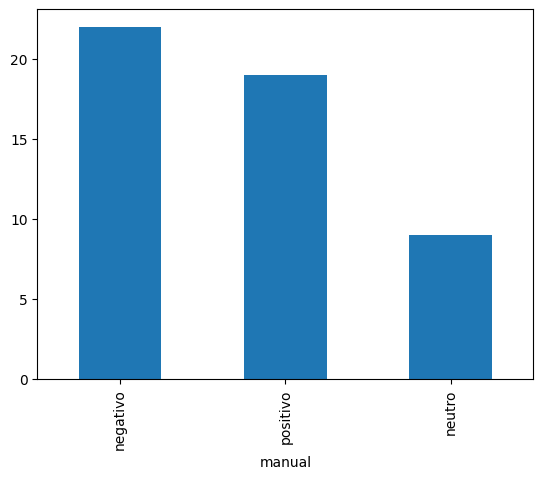

In [ ]:
# Checking ammount of examples in each category

''' We can see that "neutro" is a category with fewer examples.
A reason for that is probably because comments are usually polarized,
either positive or negative, and classifying them in neutral is
probably a little harder.'''

comments_df['manual'].value_counts().plot(kind='bar')

## Dataset de Reviews da PlayStore

In [ ]:
PS_df['sentiment_polarity'].value_counts().plot(kind='bar')

In [ ]:
PS_df["num_palavras"] = PS_df["content_normalized"].apply(
    lambda x: len(x.split()) if isinstance(x, str) else 0
)


In [ ]:
PS_df["num_palavras"].describe()


,num_palavras
count,3010.000000
mean,29.242857
std,12.137101
min,1.000000
25%,21.000000
50%,29.000000
75%,39.000000
max,63.000000


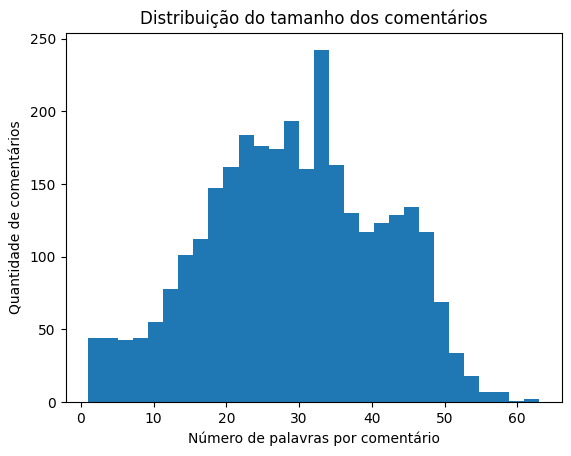

In [ ]:
plt.figure()
plt.hist(PS_df["num_palavras"], bins=30)
plt.xlabel("Número de palavras por comentário")
plt.ylabel("Quantidade de comentários")
plt.title("Distribuição do tamanho dos comentários")
plt.show()


In [ ]:
# Optional
data_f = PS_df[PS_df["num_palavras"] < 30]

In [ ]:
# Optional
df_pos = data_f[data_f['sentiment_polarity'] == "positivo"]
df_neg = data_f[data_f['sentiment_polarity'] == "negativo"]

df_pos = df_pos.sample(frac=0.5, random_state = 60)
df_neg = df_neg.sample(frac=0.6, random_state = 60)
df = data_f[data_f['sentiment_polarity'] == "neutro"]

data_f = pd.concat([df_pos, df_neg, df])

In [ ]:
PS_df = data_f

<Axes: xlabel='sentiment_polarity'>

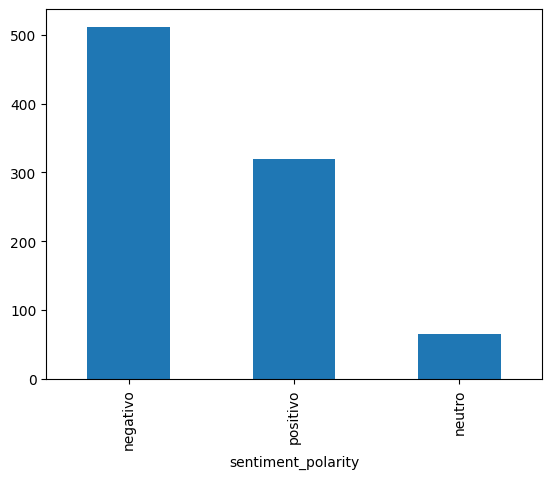

In [ ]:
PS_df['sentiment_polarity'].value_counts().plot(kind='bar')

In [ ]:
len(PS_df)

896

## Dataset de Reviews do Mercado Livre

In [ ]:
ML_df["num_palavras"] = ML_df["content_normalized"].apply(
    lambda x: len(x.split()) if isinstance(x, str) else 0
)

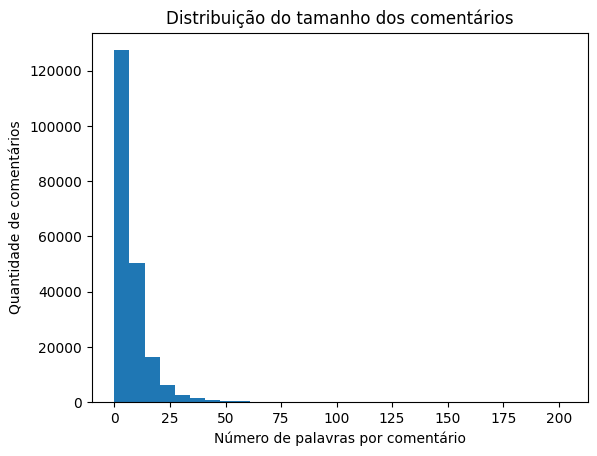

In [ ]:
plt.figure()
plt.hist(ML_df["num_palavras"], bins=30)
plt.xlabel("Número de palavras por comentário")
plt.ylabel("Quantidade de comentários")
plt.title("Distribuição do tamanho dos comentários")
plt.show()

In [ ]:
data_f = ML_df[ML_df["num_palavras"] < 5]

<Axes: xlabel='sentiment_polarity'>

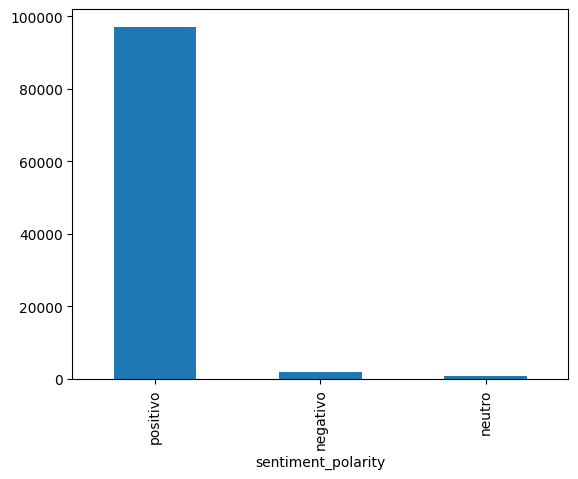

In [ ]:
data_f['sentiment_polarity'].value_counts().plot(kind='bar')

In [ ]:
df_pos = data_f[data_f['sentiment_polarity'] == "positivo"]

df_pos = df_pos.sample(frac=0.05, random_state = 60)
df = data_f[data_f['sentiment_polarity'] != "positivo"]

data_f = pd.concat([df_pos, df])

In [ ]:
ML_df = data_f

<Axes: xlabel='sentiment_polarity'>

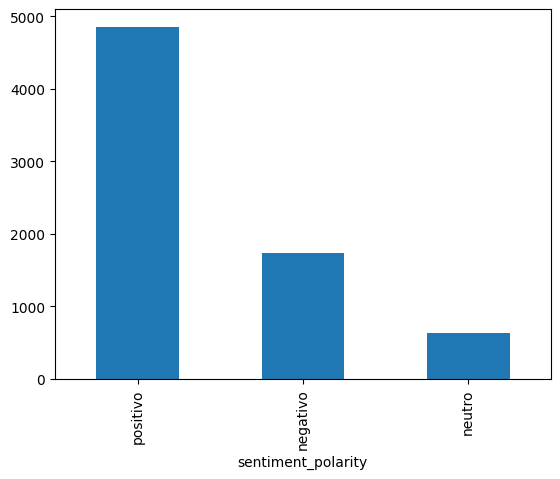

In [ ]:
ML_df['sentiment_polarity'].value_counts().plot(kind='bar')

In [ ]:
len(ML_df)

7211

## Dataset de Reviews de Livros

In [ ]:
L_df["num_palavras"] = L_df["content_normalized"].apply(
    lambda x: len(x.split()) if isinstance(x, str) else 0
)


In [ ]:
plt.figure()
plt.hist(L_df["num_palavras"], bins=30)
plt.xlabel("Número de palavras por comentário")
plt.ylabel("Quantidade de comentários")
plt.title("Distribuição do tamanho dos comentários")
plt.show()

In [ ]:
data_f = L_df[L_df["num_palavras"] < 5]

In [ ]:
data_f['sentiment_polarity'].value_counts().plot(kind='bar')

In [ ]:
df_pos = data_f[data_f['sentiment_polarity'] == "positivo"]

df_pos = df_pos.sample(frac=0.25, random_state = 60)
df = data_f[data_f['sentiment_polarity'] != "positivo"]

data_f = pd.concat([df_pos, df])

In [ ]:
L_df = data_f

In [ ]:
L_df['sentiment_polarity'].value_counts().plot(kind='bar')

In [ ]:
len(L_df)

## Dataset B2W

In [ ]:
BW_df["num_palavras"] = BW_df["content_normalized"].apply(
    lambda x: len(x.split()) if isinstance(x, str) else 0
)

In [ ]:
plt.figure()
plt.hist(BW_df["num_palavras"], bins=30)
plt.xlabel("Número de palavras por comentário")
plt.ylabel("Quantidade de comentários")
plt.title("Distribuição do tamanho dos comentários")
plt.show()

In [ ]:
data_f = BW_df[BW_df["num_palavras"] < 50]

In [ ]:
data_f['sentiment_polarity'].value_counts().plot(kind='bar')

In [ ]:
BW_df = data_f

# Método Baseado em Regras

A principal desvantagem desse método é que apesar de conseguir capturar o sentido e sentimento de palavras individuais, é muito difícil passar essa capacidade para frases completas, pois seria necessário um conjunto de regras que descrevesse precisamente como sentimento funciona no português e esse conjunto não existe. Além de não ser capaz de entender construções sociais como a ironia.

Usando o lexico OpLexicon temos um desempenho itermediário, 64% de acurácia, um dos grandes problemas é que mesmo sendo um léxico grande e bem avaliado, ainda faltam muitas palavras por o português ser um lingua muito grande. **Caso queira rodar o OpLexicon pule a célula em que o lexico é definido manualmente (Será apontada abaixo)**.

In [ ]:
lexicon = pd.read_csv("OpLexicon.csv", header=None, names = ['word', 'class', 'label'])
lexicon_dict = dict(zip(lexicon["word"], lexicon["label"]))

In [ ]:
print(lexicon_dict)

{'abafada': -1, 'abafadas': -1, 'abafado': -1, 'abafados': -1, 'abafante': -1, 'abafantes': -1, 'abaixada': -1, 'abaixadas': -1, 'abaixado': -1, 'abaixados': -1, 'abalada': -1, 'abaladas': -1, 'abalado': -1, 'abalados': -1, 'abalançado': 1, 'abalizada': 1, 'abalizadas': 1, 'abalizado': 1, 'abalizados': 1, 'abandalhada': -1, 'abandalhadas': -1, 'abandalhado': -1, 'abandalhados': -1, 'abandonada': -1, 'abandonadas': -1, 'abandonado': -1, 'abandonados': -1, 'abarbarado': 1, 'abarcante': -1, 'abarcantes': -1, 'abarrotada': -1, 'abarrotadas': -1, 'abarrotado': -1, 'abarrotados': -1, 'abastada': 1, 'abastadas': 1, 'abastado': 1, 'abastados': 1, 'abastecida': 0, 'abastecidas': 0, 'abastecido': 0, 'abastecidos': 0, 'abastoso': 1, 'abatida': -1, 'abatidas': -1, 'abatido': -1, 'abatidos': -1, 'abelhuda': -1, 'abelhudas': -1, 'abelhudo': -1, 'abelhudos': -1, 'abençoada': 1, 'abençoadas': 1, 'abençoado': 1, 'abençoados': 1, 'aberrante': -1, 'aberrantes': -1, 'aberrativa': -1, 'aberrativas': -1, 'a

Aqui definimos um lexico manualmente customisado para as nossas frases mas com lógica sólida. O desempenho com esse léxico é bem maior, passando dos 82% de acurácia. Porém não tem potencial de expansão para frases muito diferentes, diferente do uso de Léxicos grandes. **Essa célula abaixo sobrescreve as anteriores, caso queira rodar o OpLexicon pule ela.**

In [ ]:
lexicon_dict = {
    # positivos
    "bom": 1,
    "boa": 1,
    "otima": 1,
    "otimo": 1,
    "excelente": 2,
    "adorei": 2,
    "amei": 2,
    "gostei": 1,
    "curti": 1,
    "recomendo": 2,
    "top": 2,
    "show": 2,
    "parabens": 1,
    "funciona": 1,
    "cumpre": 1,
    "promete": 1,
    "resolve": 1,
    "eficiente": 1,
    "simples": 1,

    # neutros
    "ok": 0,
    "normal": 0,
    "razoavel": 0,
    "legalzinho": 0,
    "galho": 0,
    "nada": 0,
    "mais": 0,
    "quando": 0,
    "vezes": 0,

    # negativos
    "lento": -1,
    "demora": -1,
    "trava": -1,
    "confusa": -1,
    "fraco": -1,
    "problemas": -1,
    "decepcionante": -1,
    "ruim": -1,
    "pessimo": -2,
    "pessima": -2,
    "horrivel": -2,
    "odiei": -2,
    "deixa": -1,
    "pena": -1,
    "mal": -1,
}


Transformei todas as palavras em singular para trabalharmos só com isso.

In [ ]:
normalized_lexicon = {}

for word, label in lexicon_dict.items():
    norm_word = normalize_word(word)
    normalized_lexicon[norm_word] = label

lexicon_dict = normalized_lexicon
print(lexicon_dict)

{'bom': 1, 'boa': 1, 'otima': 1, 'otimo': 1, 'excelente': 2, 'adorei': 2, 'amei': 2, 'gostei': 1, 'curti': 1, 'recomendo': 2, 'top': 2, 'show': 2, 'parabem': 1, 'funciona': 1, 'cumpre': 1, 'promete': 1, 'resolve': 1, 'eficiente': 1, 'simpl': 1, 'ok': 0, 'normal': 0, 'razoavel': 0, 'legalzinho': 0, 'galho': 0, 'nada': 0, 'mais': 0, 'quando': 0, 'vez': 0, 'lento': -1, 'demora': -1, 'trava': -1, 'confusa': -1, 'fraco': -1, 'problema': -1, 'decepcionante': -1, 'ruim': -1, 'pessimo': -2, 'pessima': -2, 'horrivel': -2, 'odiei': -2, 'deixa': -1, 'pena': -1, 'mal': -1}


Aqui é definido um segundo léxico auxiliar com os "radicais" das palavras, para o caso de ter uma palavra parecida mas não igual a que está sendo procurada.

In [ ]:
normalized_lexicon_2 = {}

for word, label in lexicon_dict.items():
    norm_word = stem_word(word)
    if norm_word in normalized_lexicon_2:
        normalized_lexicon_2[norm_word] = (label + normalized_lexicon_2[norm_word]) / 2
    else:
        normalized_lexicon_2[norm_word] = label

lexicon_dict_2 = normalized_lexicon_2
print(lexicon_dict_2)

{'bom': 1, 'boa': 1, 'otim': 1.0, 'excel': 2, 'ador': 2, 'ame': 2, 'gost': 1, 'curt': 1, 'recom': 2, 'top': 2, 'show': 2, 'parab': 1, 'func': 1, 'cumpr': 1, 'promet': 1, 'resolv': 1, 'efici': 1, 'simpl': 1, 'ok': 0, 'norm': 0, 'razoa': 0, 'legal': 0, 'galh': 0, 'nad': 0, 'mais': 0, 'qu': 0, 'vez': 0, 'lent': -1, 'dem': -1, 'tr': -1, 'confus': -1, 'frac': -1, 'problem': -1, 'decepcion': -1, 'ruim': -1, 'pess': -2.0, 'horri': -2, 'odi': -2, 'deix': -1, 'pen': -1, 'mal': -1}


Aqui é realizada a classificação lidando com negações e intensificadores.

In [ ]:
classification_rule = []

negations = {"nao", "não", "nunca", "jamais"}

intensifiers = {
    "muito", "muita", "muito", "muita",
    "pouco", "pouca", "pouco", "pouca",
    "bem", "demais", "super", "extremamente"
}


for i in comments_df["comments"]:
    i = normalizar_frase(i)
    words = re.findall(r"\b\w+\b", i)
    count = 0
    hits = 0
    negate_next = False
    intense_next = False

    print(i)

    print("soma:")

    for word in words:
        word = normalize_word(word)

        # detecta negação
        if word in negations:
            print("negate")
            negate_next = True

        elif word in intensifiers:
            print("intense")
            intense_next = True

        elif word in lexicon_dict:
            hits += 1
            polarity = lexicon_dict[word]

            # aplica negação apenas na próxima palavra
            if negate_next:
                polarity *= -1
                negate_next = False

            if intense_next:
                polarity *= 2
                intense_next = False

            print(f"{count} += {polarity}")

            count += polarity

        elif stem_word(word) in lexicon_dict_2:
            hits += 1
            polarity = lexicon_dict_2[stem_word(word)]

            # aplica negação apenas na próxima palavra
            if negate_next:
                polarity *= -1
                negate_next = False

            if intense_next:
                polarity *= 2
                intense_next = False

            print(f"{count} += {polarity}")

            count += polarity

        else:
            negate_next = False
            intense_next = False
            continue

    print(hits)
    print(count)

    if count == 0:
        classification_rule.append("neutro")
    elif count > 0:
        classification_rule.append("positivo")
    else:
        classification_rule.append("negativo")


muito bom gostei bastante
soma:
intense
0 += 2
2 += 1
2
3
funciona bem
soma:
0 += 1
intense
1
1
mais menos
soma:
0 += 0
1
0
nao gostei
soma:
negate
0 += -1
1
-1
app excelente
soma:
0 += 2
1
2
demora pra carregar
soma:
0 += -1
1
-1
ok nada demais
soma:
0 += 0
0 += 0
intense
2
0
odiei experiencia
soma:
0 += -2
1
-2
bom podia melhorar
soma:
0 += 1
1
1
pessimo atendimento
soma:
0 += -2
1
-2
gostei design
soma:
0 += 1
1
1
trava vezes
soma:
0 += -1
-1 += 0
2
-1
cumpre que promete
soma:
0 += 1
1 += 1
2
2
nao ruim
soma:
negate
0 += 1
1
1
muito lento
soma:
intense
0 += -2
1
-2
adorei app
soma:
0 += 2
1
2
experiencia razoavel
soma:
0 += 0
1
0
horrivel nao recomendo
soma:
0 += -2
negate
-2 += -2
2
-4
bom demais
soma:
0 += 1
intense
1
1
deixa desejar
soma:
0 += -1
1
-1
top demais
soma:
0 += 2
intense
1
2
funciona quando quer
soma:
0 += 1
1 += 0
1 += 0
3
1
excelente servico
soma:
0 += 2
1
2
nada reclamar
soma:
0 += 0
1
0
interface confusa
soma:
0 += -1
1
-1
nao funciona direito
soma:
negate
0 += -1

In [ ]:
len(classification_rule)


50

In [ ]:
# With unknown as neutro

final_label = classification_rule

In [ ]:
accuracy = (final_label == comments_df["manual"]).mean()
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.820


In [ ]:
labels = ["positivo", "neutro", "negativo"]

cm = confusion_matrix(
    comments_df["manual"],
    final_label,
    labels=labels
)

cm

array([[16,  3,  0],
       [ 4,  5,  0],
       [ 1,  1, 20]])

In [ ]:
print(classification_report(
    comments_df["manual"],
    final_label,
    labels=labels
))

              precision    recall  f1-score   support

    positivo       0.76      0.84      0.80        19
      neutro       0.56      0.56      0.56         9
    negativo       1.00      0.91      0.95        22

    accuracy                           0.82        50
   macro avg       0.77      0.77      0.77        50
weighted avg       0.83      0.82      0.82        50



Frases que o modelo errou.

In [ ]:
final_label = pd.Series(final_label, index=comments_df.index)

wrong = comments_df[comments_df["manual"] != final_label].copy()
wrong["predict"] = final_label[comments_df["manual"] != final_label]

print(wrong)

                   comments    manual       gpt   predict
8   bom, mas podia melhorar    neutro    neutro  positivo
12     cumpre o que promete    neutro  positivo  positivo
13               nao e ruim    neutro    neutro  positivo
21     funciona quando quer  negativo  negativo  positivo
26               legalzinho  positivo    neutro    neutro
30            esperava mais  negativo  negativo    neutro
42       resolve o problema  positivo  positivo    neutro
45          quebra um galho  positivo    neutro    neutro
49          funciona normal    neutro    neutro  positivo


**Essa célula se refere ao Léxico definido manualmente.**
Analisando os erros acima podemos ver que grande parte dos erros foram em frases que a classe não é bem definida.
Tendo errado completamente apenas em alguns casos como o 21 que ele classificou como positivo, mas essa frase em específico é uma bem difícil para o modelo acertar por conter ironia.

Como o desempenho do OpLexicon foi baixo, e a estratégia manual não tem potencial de escala e poderia ser talvez considerado "roubo" nesse case, não a utilizarei na resposta final.


# Modelos

Aqui são testados vários modelos em cada dataset, os resultados foram reunidos no final em uma tabela na sessão resultados.

Vale ressaltar que para modelos usados para treinamentos foi preferido a Regressão Logística sobre outros em um primeiro momento (foi testado e aparentemente era o melhor). Em trabalhos futuross outros podem ser explorados.

Por último, stemming só foi aplicado quando o dataset era o da Play Store, em que os texts já haviam passado por esse pré-processamento, e a codificação era feita por TF-IDF e Word2Vec (em Embeddings e Fine-Tuning isso não foi feito).

## TF-IDF

### Dataset PlayStore

In [ ]:
X = PS_df["content_normalized"]
y = PS_df["sentiment_polarity"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
tfidf_word = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),   # unigrams + bigrams + trigrams
    min_df=3,
    max_df=0.9
)

tfidf_char = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),   # char n-grams
    min_df=3,
    max_df=0.9
)

tfidf = FeatureUnion([
    ("word", tfidf_word),
    ("char", tfidf_char)
])

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [ ]:
model = LinearSVC(
    class_weight="balanced",
    max_iter=3000
)

model.fit(X_train_tfidf, y_train)


LinearSVC(class_weight='balanced', max_iter=3000)

In [ ]:
y_pred = model.predict(X_test_tfidf)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))


=== Classification Report ===
              precision    recall  f1-score   support

    negativo       0.84      0.84      0.84       103
      neutro       0.43      0.23      0.30        13
    positivo       0.81      0.88      0.84        64

    accuracy                           0.81       180
   macro avg       0.69      0.65      0.66       180
weighted avg       0.80      0.81      0.80       180



In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"].apply(normalizar_frase_stem)
tfidf_comm = tfidf.transform(comments)
final_label = model.predict(tfidf_comm)
labels = ["positivo", "neutro", "negativo"]

print(classification_report(
    true_label,
    final_label,
    labels=labels
))

              precision    recall  f1-score   support

    positivo       0.65      0.68      0.67        19
      neutro       0.00      0.00      0.00         9
    negativo       0.61      0.77      0.68        22

    accuracy                           0.60        50
   macro avg       0.42      0.49      0.45        50
weighted avg       0.51      0.60      0.55        50



### Dataset Mercado Livre

In [ ]:
X = ML_df["content_normalized"]
y = ML_df["sentiment_polarity"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tfidf_word = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 3),   # unigrams + bigrams + trigrams
    min_df=3,
    max_df=0.9
)

tfidf_char = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),   # char n-grams
    min_df=3,
    max_df=0.9
)

tfidf = FeatureUnion([
    ("word", tfidf_word),
    ("char", tfidf_char)
])

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


model = LogisticRegression(
    max_iter=300,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)


LogisticRegression(class_weight='balanced', max_iter=300, n_jobs=-1)

In [ ]:
y_pred = model.predict(X_test_tfidf)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

    negativo       0.79      0.67      0.73       347
      neutro       0.31      0.50      0.38       125
    positivo       0.96      0.93      0.94       971

    accuracy                           0.83      1443
   macro avg       0.69      0.70      0.68      1443
weighted avg       0.86      0.83      0.84      1443



In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"].apply(normalizar_frase)
tfidf_comm = tfidf.transform(comments)
final_label = model.predict(tfidf_comm)
labels = ["positivo", "neutro", "negativo"]

print(classification_report(
    true_label,
    final_label,
    labels=labels
))

              precision    recall  f1-score   support

    positivo       0.67      0.84      0.74        19
      neutro       0.21      0.33      0.26         9
    negativo       0.67      0.36      0.47        22

    accuracy                           0.54        50
   macro avg       0.52      0.51      0.49        50
weighted avg       0.59      0.54      0.54        50



### Dataset Livros

In [ ]:
X = L_df["content_normalized"]
y = L_df["sentiment_polarity"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tfidf_word = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 3),   # unigrams + bigrams + trigrams
    min_df=3,
    max_df=0.9
)

tfidf_char = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),   # char n-grams
    min_df=3,
    max_df=0.9
)

tfidf = FeatureUnion([
    ("word", tfidf_word),
    ("char", tfidf_char)
])

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


model = LogisticRegression(
    max_iter=300,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)


LogisticRegression(class_weight='balanced', max_iter=300, n_jobs=-1)

In [ ]:
y_pred = model.predict(X_test_tfidf)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

    negativo       0.47      0.39      0.43        90
      neutro       0.18      0.33      0.23        21
    positivo       0.54      0.53      0.53       102

    accuracy                           0.45       213
   macro avg       0.40      0.42      0.40       213
weighted avg       0.48      0.45      0.46       213



In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"].apply(normalizar_frase)
tfidf_comm = tfidf.transform(comments)
final_label = model.predict(tfidf_comm)
labels = ["positivo", "neutro", "negativo"]

print(classification_report(
    true_label,
    final_label,
    labels=labels
))

              precision    recall  f1-score   support

    positivo       0.50      0.63      0.56        19
      neutro       0.29      0.22      0.25         9
    negativo       0.53      0.45      0.49        22

    accuracy                           0.48        50
   macro avg       0.44      0.44      0.43        50
weighted avg       0.47      0.48      0.47        50



### Dataset B2W

In [ ]:
X = BW_df["content_normalized"]
y = BW_df["sentiment_polarity"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tfidf_word = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 3),   # unigrams + bigrams + trigrams
    min_df=3,
    max_df=0.9
)

tfidf_char = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),   # char n-grams
    min_df=3,
    max_df=0.9
)

tfidf = FeatureUnion([
    ("word", tfidf_word),
    ("char", tfidf_char)
])

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


model = LogisticRegression(
    max_iter=300,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=300, n_jobs=-1)

In [ ]:
y_pred = model.predict(X_test_tfidf)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

    negativo       0.80      0.86      0.83      2933
      neutro       0.65      0.61      0.63      3121
    positivo       0.76      0.76      0.76      3192

    accuracy                           0.74      9246
   macro avg       0.74      0.74      0.74      9246
weighted avg       0.74      0.74      0.74      9246



In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"].apply(normalizar_frase)
tfidf_comm = tfidf.transform(comments)
final_label = model.predict(tfidf_comm)
labels = ["positivo", "neutro", "negativo"]

print(classification_report(
    true_label,
    final_label,
    labels=labels
))

              precision    recall  f1-score   support

    positivo       0.86      0.63      0.73        19
      neutro       0.22      0.44      0.30         9
    negativo       0.83      0.68      0.75        22

    accuracy                           0.62        50
   macro avg       0.64      0.59      0.59        50
weighted avg       0.73      0.62      0.66        50



Com o TF-IDF acredito que o desempenho abaixo se deva a falta de um dataset de treino que se assemelhasse com os comentários e fosse mais balanceado.
Ficou claro que esse tipo de dado costume ser severamente inclinado para a classe positiva.

## Word2Vec

### Play Store

In [ ]:
X = PS_df["content_normalized"]
y = PS_df["sentiment_polarity"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
X_train_tokens = X_train.apply(lambda x: x.split())
X_test_tokens = X_test.apply(lambda x: x.split())


In [ ]:
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=0  # CBOW (sg=1 seria Skip-gram)
)


In [ ]:
def sentence_vector(tokens, model, vector_size):
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(vectors, axis=0)


In [ ]:
X_train_w2v = np.vstack([
    sentence_vector(tokens, w2v_model, 100)
    for tokens in X_train_tokens
])

X_test_w2v = np.vstack([
    sentence_vector(tokens, w2v_model, 100)
    for tokens in X_test_tokens
])


In [ ]:
model_w2v = LogisticRegression(
    max_iter=300,
    class_weight="balanced",
    n_jobs=-1
)

model_w2v.fit(X_train_w2v, y_train)


LogisticRegression(class_weight='balanced', max_iter=300, n_jobs=-1)

In [ ]:
y_pred = model_w2v.predict(X_test_w2v)

labels = ["positivo", "neutro", "negativo"]

print("=== Word2Vec + Logistic Regression ===")
print(classification_report(y_test, y_pred, labels=labels))


=== Word2Vec + Logistic Regression ===
              precision    recall  f1-score   support

    positivo       0.53      0.12      0.20        64
      neutro       0.09      0.62      0.16        13
    negativo       0.62      0.47      0.53       103

    accuracy                           0.36       180
   macro avg       0.41      0.40      0.30       180
weighted avg       0.55      0.36      0.39       180



In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"].apply(normalizar_frase_stem)
comm_tokens = comments.apply(lambda x: x.split())
w2v_comm = np.vstack([
    sentence_vector(tokens, w2v_model, 100)
    for tokens in comm_tokens
])
final_label = model_w2v.predict(w2v_comm)
labels = ["positivo", "neutro", "negativo"]

print(classification_report(
    true_label,
    final_label,
    labels=labels
))

              precision    recall  f1-score   support

    positivo       0.33      0.05      0.09        19
      neutro       0.19      0.67      0.29         9
    negativo       0.40      0.27      0.32        22

    accuracy                           0.26        50
   macro avg       0.31      0.33      0.24        50
weighted avg       0.34      0.26      0.23        50



### Mercado Livre

In [ ]:
X = ML_df["content_normalized"]
y = ML_df["sentiment_polarity"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
X_train_tokens = X_train.apply(lambda x: x.split())
X_test_tokens = X_test.apply(lambda x: x.split())


In [ ]:
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=0  # CBOW (sg=1 seria Skip-gram)
)


In [ ]:
def sentence_vector(tokens, model, vector_size):
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(vectors, axis=0)


In [ ]:
X_train_w2v = np.vstack([
    sentence_vector(tokens, w2v_model, 100)
    for tokens in X_train_tokens
])

X_test_w2v = np.vstack([
    sentence_vector(tokens, w2v_model, 100)
    for tokens in X_test_tokens
])


In [ ]:
model_w2v = LogisticRegression(
    max_iter=300,
    class_weight="balanced",
    n_jobs=-1
)

model_w2v.fit(X_train_w2v, y_train)


LogisticRegression(class_weight='balanced', max_iter=300, n_jobs=-1)

In [ ]:
y_pred = model_w2v.predict(X_test_w2v)

labels = ["positivo", "neutro", "negativo"]

print("=== Word2Vec + Logistic Regression ===")
print(classification_report(y_test, y_pred, labels=labels))


=== Word2Vec + Logistic Regression ===
              precision    recall  f1-score   support

    positivo       0.83      0.77      0.80       971
      neutro       0.20      0.46      0.28       125
    negativo       0.31      0.24      0.27       347

    accuracy                           0.62      1443
   macro avg       0.45      0.49      0.45      1443
weighted avg       0.65      0.62      0.63      1443



In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"].apply(normalizar_frase_stem)
comm_tokens = comments.apply(lambda x: x.split())
w2v_comm = np.vstack([
    sentence_vector(tokens, w2v_model, 100)
    for tokens in comm_tokens
])
final_label = model_w2v.predict(w2v_comm)
labels = ["positivo", "neutro", "negativo"]

print(classification_report(
    true_label,
    final_label,
    labels=labels
))

              precision    recall  f1-score   support

    positivo       0.45      0.95      0.61        19
      neutro       0.33      0.11      0.17         9
    negativo       0.86      0.27      0.41        22

    accuracy                           0.50        50
   macro avg       0.55      0.44      0.40        50
weighted avg       0.61      0.50      0.44        50



### Livros

In [ ]:
X = L_df["content_normalized"]
y = L_df["sentiment_polarity"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
X_train_tokens = X_train.apply(lambda x: x.split())
X_test_tokens = X_test.apply(lambda x: x.split())


In [ ]:
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=0  # CBOW (sg=1 seria Skip-gram)
)


In [ ]:
def sentence_vector(tokens, model, vector_size):
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(vectors, axis=0)


In [ ]:
X_train_w2v = np.vstack([
    sentence_vector(tokens, w2v_model, 100)
    for tokens in X_train_tokens
])

X_test_w2v = np.vstack([
    sentence_vector(tokens, w2v_model, 100)
    for tokens in X_test_tokens
])


In [ ]:
model_w2v = LogisticRegression(
    max_iter=300,
    class_weight="balanced",
    n_jobs=-1
)

model_w2v.fit(X_train_w2v, y_train)


LogisticRegression(class_weight='balanced', max_iter=300, n_jobs=-1)

In [ ]:
y_pred = model_w2v.predict(X_test_w2v)

labels = ["positivo", "neutro", "negativo"]

print("=== Word2Vec + Logistic Regression ===")
print(classification_report(y_test, y_pred, labels=labels))


=== Word2Vec + Logistic Regression ===
              precision    recall  f1-score   support

    positivo       0.58      0.19      0.28       102
      neutro       0.11      0.24      0.15        21
    negativo       0.43      0.63      0.51        90

    accuracy                           0.38       213
   macro avg       0.37      0.35      0.31       213
weighted avg       0.47      0.38      0.37       213



In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"].apply(normalizar_frase)
comm_tokens = comments.apply(lambda x: x.split())
w2v_comm = np.vstack([
    sentence_vector(tokens, w2v_model, 100)
    for tokens in comm_tokens
])
final_label = model_w2v.predict(w2v_comm)
labels = ["positivo", "neutro", "negativo"]

print(classification_report(
    true_label,
    final_label,
    labels=labels
))

              precision    recall  f1-score   support

    positivo       0.75      0.16      0.26        19
      neutro       0.31      0.44      0.36         9
    negativo       0.48      0.73      0.58        22

    accuracy                           0.46        50
   macro avg       0.51      0.44      0.40        50
weighted avg       0.55      0.46      0.42        50



### B2W

In [ ]:
X = BW_df["content_normalized"]
y = BW_df["sentiment_polarity"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
X_train_tokens = X_train.apply(lambda x: x.split())
X_test_tokens = X_test.apply(lambda x: x.split())


In [ ]:
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=0  # CBOW (sg=1 seria Skip-gram)
)


In [ ]:
def sentence_vector(tokens, model, vector_size):
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(vectors, axis=0)


In [ ]:
X_train_w2v = np.vstack([
    sentence_vector(tokens, w2v_model, 100)
    for tokens in X_train_tokens
])

X_test_w2v = np.vstack([
    sentence_vector(tokens, w2v_model, 100)
    for tokens in X_test_tokens
])


In [ ]:
model_w2v = LogisticRegression(
    max_iter=300,
    class_weight="balanced",
    n_jobs=-1
)

model_w2v.fit(X_train_w2v, y_train)


LogisticRegression(class_weight='balanced', max_iter=300, n_jobs=-1)

In [ ]:
y_pred = model_w2v.predict(X_test_w2v)

labels = ["positivo", "neutro", "negativo"]

print("=== Word2Vec + Logistic Regression ===")
print(classification_report(y_test, y_pred, labels=labels))


=== Word2Vec + Logistic Regression ===
              precision    recall  f1-score   support

    positivo       0.74      0.71      0.73      3192
      neutro       0.60      0.55      0.57      3121
    negativo       0.74      0.84      0.79      2933

    accuracy                           0.70      9246
   macro avg       0.69      0.70      0.70      9246
weighted avg       0.69      0.70      0.69      9246



In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"].apply(normalizar_frase)
comm_tokens = comments.apply(lambda x: x.split())
w2v_comm = np.vstack([
    sentence_vector(tokens, w2v_model, 100)
    for tokens in comm_tokens
])
final_label = model_w2v.predict(w2v_comm)
labels = ["positivo", "neutro", "negativo"]

print(classification_report(
    true_label,
    final_label,
    labels=labels
))

              precision    recall  f1-score   support

    positivo       0.62      0.68      0.65        19
      neutro       0.14      0.22      0.17         9
    negativo       0.80      0.55      0.65        22

    accuracy                           0.54        50
   macro avg       0.52      0.48      0.49        50
weighted avg       0.61      0.54      0.56        50



## Embeddings

### Play Store

In [ ]:
texts = PS_df["content"]
labels = PS_df["sentiment_polarity"]

In [ ]:
# Mapeamento explícito das classes
label2id = {
    "positivo": 0,
    "neutro": 1,
    "negativo": 2
}

id2label = {v: k for k, v in label2id.items()}

y = np.array([label2id[label] for label in labels])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)

# Modo avaliação (desliga dropout)
bert_model.eval()

# Usar GPU se disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(29794, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
def generate_embeddings(texts, tokenizer, model, device, max_length=128):
    embeddings = []

    with torch.no_grad():
        for text in texts:
            encoded = tokenizer(
                text,
                padding="max_length",
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )

            encoded = {k: v.to(device) for k, v in encoded.items()}

            outputs = model(**encoded)

            # Embedding do token [CLS]
            cls_embedding = outputs.last_hidden_state[:, 0, :]

            embeddings.append(cls_embedding.cpu().numpy())

    return np.vstack(embeddings)


In [ ]:
X_train_emb = generate_embeddings(X_train, tokenizer, bert_model, device)
X_test_emb  = generate_embeddings(X_test, tokenizer, bert_model, device)


In [ ]:
classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"  # ajuda com classe neutra
)

classifier.fit(X_train_emb, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred = classifier.predict(X_test_emb)

print(classification_report(
    y_test,
    y_pred,
    target_names=["positivo", "neutro", "negativo"]
))


              precision    recall  f1-score   support

    positivo       0.76      0.81      0.79        64
      neutro       0.25      0.38      0.30        13
    negativo       0.80      0.72      0.76       103

    accuracy                           0.73       180
   macro avg       0.61      0.64      0.62       180
weighted avg       0.75      0.73      0.74       180



In [ ]:
def predict_sentiment(text):
    emb = generate_embeddings([text], tokenizer, bert_model, device)
    pred = classifier.predict(emb)[0]
    return id2label[pred]


# Exemplo
print(predict_sentiment("O aplicativo funciona bem e é fácil de usar"))
print(predict_sentiment("Não gostei da atualização"))
print(predict_sentiment("Funciona como esperado"))


positivo
neutro
neutro


In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"].apply(normalizar_frase)
emb_comm  = generate_embeddings(comments, tokenizer, bert_model, device)
final_label = classifier.predict(emb_comm)

final_label_str = [id2label[i] for i in final_label]

print(classification_report(
    true_label,
    final_label_str,
    labels=["positivo", "neutro", "negativo"]
))

              precision    recall  f1-score   support

    positivo       0.82      0.74      0.78        19
      neutro       0.09      0.11      0.10         9
    negativo       0.59      0.59      0.59        22

    accuracy                           0.56        50
   macro avg       0.50      0.48      0.49        50
weighted avg       0.59      0.56      0.57        50



### Mercado Livre

In [ ]:
texts = ML_df["content"]
labels = ML_df["sentiment_polarity"]

In [ ]:
# Mapeamento explícito das classes
label2id = {
    "positivo": 0,
    "neutro": 1,
    "negativo": 2
}

id2label = {v: k for k, v in label2id.items()}

y = np.array([label2id[label] for label in labels])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)

# Modo avaliação (desliga dropout)
bert_model.eval()

# Usar GPU se disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(29794, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
def generate_embeddings(texts, tokenizer, model, device, max_length=128):
    embeddings = []

    with torch.no_grad():
        for text in texts:
            encoded = tokenizer(
                text,
                padding="max_length",
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )

            encoded = {k: v.to(device) for k, v in encoded.items()}

            outputs = model(**encoded)

            # Embedding do token [CLS]
            cls_embedding = outputs.last_hidden_state[:, 0, :]

            embeddings.append(cls_embedding.cpu().numpy())

    return np.vstack(embeddings)


In [ ]:
X_train_emb = generate_embeddings(X_train, tokenizer, bert_model, device)
X_test_emb  = generate_embeddings(X_test, tokenizer, bert_model, device)


In [ ]:
classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"  # ajuda com classe neutra
)

classifier.fit(X_train_emb, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred = classifier.predict(X_test_emb)

print(classification_report(
    y_test,
    y_pred,
    target_names=["positivo", "neutro", "negativo"]
))


              precision    recall  f1-score   support

    positivo       0.97      0.95      0.96       971
      neutro       0.31      0.49      0.38       125
    negativo       0.76      0.64      0.69       347

    accuracy                           0.83      1443
   macro avg       0.68      0.69      0.68      1443
weighted avg       0.86      0.83      0.84      1443



In [ ]:
def predict_sentiment(text):
    emb = generate_embeddings([text], tokenizer, bert_model, device)
    pred = classifier.predict(emb)[0]
    return id2label[pred]


# Exemplo
print(predict_sentiment("O aplicativo funciona bem e é fácil de usar"))
print(predict_sentiment("Não gostei da atualização"))
print(predict_sentiment("Funciona como esperado"))


positivo
positivo
positivo


In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"].apply(normalizar_frase)
emb_comm  = generate_embeddings(comments, tokenizer, bert_model, device)
final_label = classifier.predict(emb_comm)

final_label_str = [id2label[i] for i in final_label]

print(classification_report(
    true_label,
    final_label_str,
    labels=["positivo", "neutro", "negativo"]
))

              precision    recall  f1-score   support

    positivo       0.67      0.84      0.74        19
      neutro       0.07      0.11      0.09         9
    negativo       0.67      0.36      0.47        22

    accuracy                           0.50        50
   macro avg       0.47      0.44      0.43        50
weighted avg       0.56      0.50      0.51        50



### Livros

In [ ]:
texts = L_df["content"]
labels = L_df["sentiment_polarity"]

In [ ]:
# Mapeamento explícito das classes
label2id = {
    "positivo": 0,
    "neutro": 1,
    "negativo": 2
}

id2label = {v: k for k, v in label2id.items()}

y = np.array([label2id[label] for label in labels])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)

# Modo avaliação (desliga dropout)
bert_model.eval()

# Usar GPU se disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(29794, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
def generate_embeddings(texts, tokenizer, model, device, max_length=128):
    embeddings = []

    with torch.no_grad():
        for text in texts:
            encoded = tokenizer(
                text,
                padding="max_length",
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )

            encoded = {k: v.to(device) for k, v in encoded.items()}

            outputs = model(**encoded)

            # Embedding do token [CLS]
            cls_embedding = outputs.last_hidden_state[:, 0, :]

            embeddings.append(cls_embedding.cpu().numpy())

    return np.vstack(embeddings)


In [ ]:
X_train_emb = generate_embeddings(X_train, tokenizer, bert_model, device)
X_test_emb  = generate_embeddings(X_test, tokenizer, bert_model, device)


In [ ]:
classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"  # ajuda com classe neutra
)

classifier.fit(X_train_emb, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred = classifier.predict(X_test_emb)

print(classification_report(
    y_test,
    y_pred,
    target_names=["positivo", "neutro", "negativo"]
))


              precision    recall  f1-score   support

    positivo       0.58      0.56      0.57       102
      neutro       0.24      0.43      0.31        21
    negativo       0.50      0.42      0.46        90

    accuracy                           0.49       213
   macro avg       0.44      0.47      0.44       213
weighted avg       0.51      0.49      0.50       213



In [ ]:
def predict_sentiment(text):
    emb = generate_embeddings([text], tokenizer, bert_model, device)
    pred = classifier.predict(emb)[0]
    return id2label[pred]


# Exemplo
print(predict_sentiment("O aplicativo funciona bem e é fácil de usar"))
print(predict_sentiment("Não gostei da atualização"))
print(predict_sentiment("Funciona como esperado"))


positivo
negativo
positivo


In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"].apply(normalizar_frase)
emb_comm  = generate_embeddings(comments, tokenizer, bert_model, device)
final_label = classifier.predict(emb_comm)

final_label_str = [id2label[i] for i in final_label]

print(classification_report(
    true_label,
    final_label_str,
    labels=["positivo", "neutro", "negativo"]
))

              precision    recall  f1-score   support

    positivo       0.65      0.68      0.67        19
      neutro       1.00      0.11      0.20         9
    negativo       0.66      0.86      0.75        22

    accuracy                           0.66        50
   macro avg       0.77      0.55      0.54        50
weighted avg       0.72      0.66      0.62        50



### B2W

In [ ]:
texts = BW_df["content"]
labels = BW_df["sentiment_polarity"]

In [ ]:
# Mapeamento explícito das classes
label2id = {
    "positivo": 0,
    "neutro": 1,
    "negativo": 2
}

id2label = {v: k for k, v in label2id.items()}

y = np.array([label2id[label] for label in labels])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)

# Modo avaliação (desliga dropout)
bert_model.eval()

# Usar GPU se disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(29794, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
def generate_embeddings(texts, tokenizer, model, device, max_length=128):
    embeddings = []

    with torch.no_grad():
        for text in texts:
            encoded = tokenizer(
                text,
                padding="max_length",
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )

            encoded = {k: v.to(device) for k, v in encoded.items()}

            outputs = model(**encoded)

            # Embedding do token [CLS]
            cls_embedding = outputs.last_hidden_state[:, 0, :]

            embeddings.append(cls_embedding.cpu().numpy())

    return np.vstack(embeddings)


In [ ]:
X_train_emb = generate_embeddings(X_train, tokenizer, bert_model, device)
X_test_emb  = generate_embeddings(X_test, tokenizer, bert_model, device)


In [ ]:
classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"  # ajuda com classe neutra
)

classifier.fit(X_train_emb, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred = classifier.predict(X_test_emb)

print(classification_report(
    y_test,
    y_pred,
    target_names=["positivo", "neutro", "negativo"]
))


              precision    recall  f1-score   support

    positivo       0.75      0.77      0.76      3192
      neutro       0.64      0.58      0.61      3121
    negativo       0.80      0.86      0.83      2933

    accuracy                           0.73      9246
   macro avg       0.73      0.74      0.73      9246
weighted avg       0.73      0.73      0.73      9246



In [ ]:
def predict_sentiment(text):
    emb = generate_embeddings([text], tokenizer, bert_model, device)
    pred = classifier.predict(emb)[0]
    return id2label[pred]


# Exemplo
print(predict_sentiment("O aplicativo funciona bem e é fácil de usar"))
print(predict_sentiment("Não gostei da atualização"))
print(predict_sentiment("Funciona como esperado"))


neutro
negativo
positivo


In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"].apply(normalizar_frase)
emb_comm  = generate_embeddings(comments, tokenizer, bert_model, device)
final_label = classifier.predict(emb_comm)

final_label_str = [id2label[i] for i in final_label]

print(classification_report(
    true_label,
    final_label_str,
    labels=["positivo", "neutro", "negativo"]
))

              precision    recall  f1-score   support

    positivo       0.86      0.63      0.73        19
      neutro       0.29      0.56      0.38         9
    negativo       0.74      0.64      0.68        22

    accuracy                           0.62        50
   macro avg       0.63      0.61      0.60        50
weighted avg       0.70      0.62      0.65        50



## Fine-Tuning

### PlayStore

In [ ]:
texts = PS_df["content"].astype(str).tolist()
labels = PS_df["sentiment_polarity"].tolist()

In [ ]:
label2id = {
    "positivo": 0,
    "neutro": 1,
    "negativo": 2
}

id2label = {v: k for k, v in label2id.items()}

y = np.array([label2id[l] for l in labels])


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    texts,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


In [ ]:
train_dataset = SentimentDataset(X_train, y_train, tokenizer)
val_dataset   = SentimentDataset(X_val, y_val, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)


In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)


In [ ]:
EPOCHS = 3  # geralmente 2–4 é suficiente

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} - Train loss: {avg_loss:.4f}")


Epoch 1/3 - Train loss: 0.8367
Epoch 2/3 - Train loss: 0.5547
Epoch 3/3 - Train loss: 0.3485


In [ ]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(batch["labels"].cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["positivo", "neutro", "negativo"]
))


              precision    recall  f1-score   support

    positivo       0.80      0.94      0.86        64
      neutro       0.67      0.15      0.25        13
    negativo       0.86      0.85      0.86       103

    accuracy                           0.83       180
   macro avg       0.78      0.65      0.66       180
weighted avg       0.83      0.83      0.82       180



In [ ]:
def predict_sentiment(text):
    model.eval()

    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(**encoding)
        pred = torch.argmax(outputs.logits, dim=1).item()

    return id2label[pred]


print(predict_sentiment("O aplicativo é ótimo e muito fácil de usar"))
print(predict_sentiment("Não mudou muita coisa"))
print(predict_sentiment("Péssima atualização, parou de funcionar"))


positivo
neutro
negativo


In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"]
final_label = []
for i in comments:
  final_label.append(predict_sentiment(i))

print(classification_report(
    true_label,
    final_label,
    target_names=["positivo", "neutro", "negativo"]
))

              precision    recall  f1-score   support

    positivo       0.67      0.64      0.65        22
      neutro       0.20      0.22      0.21         9
    negativo       0.84      0.84      0.84        19

    accuracy                           0.64        50
   macro avg       0.57      0.57      0.57        50
weighted avg       0.65      0.64      0.64        50



In [ ]:
final_label = pd.Series(final_label, index=comments_df.index)

wrong = comments_df[comments_df["manual"] != final_label].copy()
wrong["predict"] = final_label[comments_df["manual"] != final_label]

print(wrong)

                   comments    manual       gpt   predict
2             mais ou menos    neutro    neutro  negativo
3                nao gostei  negativo  negativo    neutro
8   bom, mas podia melhorar    neutro    neutro  positivo
12     cumpre o que promete    neutro  positivo  negativo
13               nao e ruim    neutro    neutro  negativo
16     experiencia razoavel    neutro    neutro  positivo
21     funciona quando quer  negativo  negativo    neutro
23          nada a reclamar    neutro  positivo  negativo
25     nao funciona direito  negativo  negativo    neutro
26               legalzinho  positivo    neutro    neutro
30            esperava mais  negativo  negativo    neutro
34     problemas frequentes  negativo  negativo    neutro
36                nao curti  negativo  negativo    neutro
41      pessima usabilidade  negativo  negativo  positivo
42       resolve o problema  positivo  positivo  negativo
45          quebra um galho  positivo    neutro  negativo
48          na

### Mercado Livre

In [ ]:
texts = ML_df["content"].astype(str).tolist()
labels = ML_df["sentiment_polarity"].tolist()

In [ ]:
label2id = {
    "positivo": 0,
    "neutro": 1,
    "negativo": 2
}

id2label = {v: k for k, v in label2id.items()}

y = np.array([label2id[l] for l in labels])


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    texts,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


In [ ]:
train_dataset = SentimentDataset(X_train, y_train, tokenizer)
val_dataset   = SentimentDataset(X_val, y_val, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)


In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)


In [ ]:
EPOCHS = 3  # geralmente 2–4 é suficiente

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} - Train loss: {avg_loss:.4f}")


Epoch 1/3 - Train loss: 0.4170
Epoch 2/3 - Train loss: 0.3228
Epoch 3/3 - Train loss: 0.2867


In [ ]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(batch["labels"].cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["positivo", "neutro", "negativo"]
))


              precision    recall  f1-score   support

    positivo       0.95      0.98      0.96       971
      neutro       0.36      0.25      0.30       125
    negativo       0.77      0.78      0.77       347

    accuracy                           0.87      1443
   macro avg       0.69      0.67      0.68      1443
weighted avg       0.85      0.87      0.86      1443



In [ ]:
def predict_sentiment(text):
    model.eval()

    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(**encoding)
        pred = torch.argmax(outputs.logits, dim=1).item()

    return id2label[pred]


print(predict_sentiment("O aplicativo é ótimo e muito fácil de usar"))
print(predict_sentiment("Não mudou muita coisa"))
print(predict_sentiment("Péssima atualização, parou de funcionar"))


positivo
negativo
negativo


In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"]
final_label = []
for i in comments:
  final_label.append(predict_sentiment(i))

print(classification_report(
    true_label,
    final_label,
    target_names=["positivo", "neutro", "negativo"]
))

              precision    recall  f1-score   support

    positivo       0.76      0.59      0.67        22
      neutro       0.12      0.11      0.12         9
    negativo       0.68      0.89      0.77        19

    accuracy                           0.62        50
   macro avg       0.52      0.53      0.52        50
weighted avg       0.62      0.62      0.61        50



In [ ]:
final_label = pd.Series(final_label, index=comments_df.index)

wrong = comments_df[comments_df["manual"] != final_label].copy()
wrong["predict"] = final_label[comments_df["manual"] != final_label]

print(wrong)

                     comments    manual       gpt   predict
5         demora pra carregar  negativo  negativo    neutro
6             ok, nada demais    neutro    neutro  positivo
7         odiei a experiencia  negativo  negativo  positivo
8     bom, mas podia melhorar    neutro    neutro  positivo
12       cumpre o que promete    neutro  positivo  positivo
13                 nao e ruim    neutro    neutro  negativo
14                muito lento  negativo  negativo    neutro
16       experiencia razoavel    neutro    neutro  positivo
19            deixa a desejar  negativo  negativo    neutro
21       funciona quando quer  negativo  negativo  positivo
23            nada a reclamar    neutro  positivo  negativo
27                   bem ruim  negativo  negativo    neutro
28                     app ok    neutro    neutro  positivo
30              esperava mais  negativo  negativo    neutro
36                  nao curti  negativo  negativo    neutro
39  mais lento que o esperado  negativo 

In [ ]:
Best_result = pd.DataFrame()
Best_result["text"] = comments
Best_result["label"] = final_label

### Livros

In [ ]:
texts = L_df["content"].astype(str).tolist()
labels = L_df["sentiment_polarity"].tolist()

In [ ]:
label2id = {
    "positivo": 0,
    "neutro": 1,
    "negativo": 2
}

id2label = {v: k for k, v in label2id.items()}

y = np.array([label2id[l] for l in labels])


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    texts,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


In [ ]:
train_dataset = SentimentDataset(X_train, y_train, tokenizer)
val_dataset   = SentimentDataset(X_val, y_val, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)


In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)


In [ ]:
EPOCHS = 3  # geralmente 2–4 é suficiente

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} - Train loss: {avg_loss:.4f}")


Epoch 1/3 - Train loss: 0.9604
Epoch 2/3 - Train loss: 0.8751
Epoch 3/3 - Train loss: 0.7102


In [ ]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(batch["labels"].cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["positivo", "neutro", "negativo"]
))


              precision    recall  f1-score   support

    positivo       0.69      0.74      0.71       102
      neutro       0.00      0.00      0.00        21
    negativo       0.58      0.68      0.63        90

    accuracy                           0.64       213
   macro avg       0.43      0.47      0.45       213
weighted avg       0.58      0.64      0.61       213



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
def predict_sentiment(text):
    model.eval()

    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(**encoding)
        pred = torch.argmax(outputs.logits, dim=1).item()

    return id2label[pred]


print(predict_sentiment("O aplicativo é ótimo e muito fácil de usar"))
print(predict_sentiment("Não mudou muita coisa"))
print(predict_sentiment("Péssima atualização, parou de funcionar"))


positivo
negativo
negativo


In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"]
final_label = []
for i in comments:
  final_label.append(predict_sentiment(i))

print(classification_report(
    true_label,
    final_label,
    target_names=["positivo", "neutro", "negativo"]
))

              precision    recall  f1-score   support

    positivo       0.68      0.95      0.79        22
      neutro       0.00      0.00      0.00         9
    negativo       0.84      0.84      0.84        19

    accuracy                           0.74        50
   macro avg       0.51      0.60      0.54        50
weighted avg       0.62      0.74      0.67        50



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
final_label = pd.Series(final_label, index=comments_df.index)

wrong = comments_df[comments_df["manual"] != final_label].copy()
wrong["predict"] = final_label[comments_df["manual"] != final_label]

print(wrong)

                      comments    manual       gpt   predict
0   muito bom, gostei bastante  positivo  positivo  negativo
2                mais ou menos    neutro    neutro  negativo
6              ok, nada demais    neutro    neutro  negativo
8      bom, mas podia melhorar    neutro    neutro  negativo
12        cumpre o que promete    neutro  positivo  positivo
13                  nao e ruim    neutro    neutro  negativo
16        experiencia razoavel    neutro    neutro  negativo
21        funciona quando quer  negativo  negativo  positivo
23             nada a reclamar    neutro  positivo  negativo
26                  legalzinho  positivo    neutro  negativo
28                      app ok    neutro    neutro  negativo
45             quebra um galho  positivo    neutro  negativo
49             funciona normal    neutro    neutro  positivo


### B2W

In [ ]:
texts = BW_df["content"].astype(str).tolist()
labels = BW_df["sentiment_polarity"].tolist()

In [ ]:
label2id = {
    "positivo": 0,
    "neutro": 1,
    "negativo": 2
}

id2label = {v: k for k, v in label2id.items()}

y = np.array([label2id[l] for l in labels])


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    texts,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


In [ ]:
train_dataset = SentimentDataset(X_train, y_train, tokenizer)
val_dataset   = SentimentDataset(X_val, y_val, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)


In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)


In [ ]:
EPOCHS = 3  # geralmente 2–4 é suficiente

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} - Train loss: {avg_loss:.4f}")


Epoch 1/3 - Train loss: 0.5680
Epoch 2/3 - Train loss: 0.4669
Epoch 3/3 - Train loss: 0.3706


In [ ]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(batch["labels"].cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["positivo", "neutro", "negativo"]
))


              precision    recall  f1-score   support

    positivo       0.78      0.81      0.80      3192
      neutro       0.68      0.65      0.67      3121
    negativo       0.86      0.85      0.85      2933

    accuracy                           0.77      9246
   macro avg       0.77      0.77      0.77      9246
weighted avg       0.77      0.77      0.77      9246



In [ ]:
def predict_sentiment(text):
    model.eval()

    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(**encoding)
        pred = torch.argmax(outputs.logits, dim=1).item()

    return id2label[pred]


print(predict_sentiment("O aplicativo é ótimo e muito fácil de usar"))
print(predict_sentiment("Não mudou muita coisa"))
print(predict_sentiment("Péssima atualização, parou de funcionar"))


positivo
neutro
negativo


In [ ]:
true_label = comments_df["manual"]

comments = comments_df["comments"]
final_label = []
for i in comments:
  final_label.append(predict_sentiment(i))

print(classification_report(
    true_label,
    final_label,
    target_names=["positivo", "neutro", "negativo"]
))

              precision    recall  f1-score   support

    positivo       1.00      0.59      0.74        22
      neutro       0.29      0.78      0.42         9
    negativo       0.85      0.58      0.69        19

    accuracy                           0.62        50
   macro avg       0.71      0.65      0.62        50
weighted avg       0.81      0.62      0.66        50



In [ ]:
final_label = pd.Series(final_label, index=comments_df.index)

wrong = comments_df[comments_df["manual"] != final_label].copy()
wrong["predict"] = final_label[comments_df["manual"] != final_label]

print(wrong)

                     comments    manual       gpt   predict
1                funciona bem  positivo  positivo    neutro
5         demora pra carregar  negativo  negativo    neutro
10           gostei do design  positivo  positivo    neutro
11             trava as vezes  negativo  negativo    neutro
12       cumpre o que promete    neutro  positivo  positivo
14                muito lento  negativo  negativo    neutro
21       funciona quando quer  negativo  negativo    neutro
23            nada a reclamar    neutro  positivo  positivo
26                 legalzinho  positivo    neutro    neutro
30              esperava mais  negativo  negativo    neutro
32              mal otimizado  negativo  negativo    neutro
34       problemas frequentes  negativo  negativo    neutro
35        simples e eficiente  positivo  positivo    neutro
38                  recomendo  positivo  positivo    neutro
39  mais lento que o esperado  negativo  negativo    neutro
40            boa experiencia  positivo 

# Modelos Não Supervisionados

Tentativa de resolução usando clusters, não foi muito explorada.

## Clusters

In [ ]:
df_balanced = (
    ML_df
    .groupby("sentiment_polarity", group_keys=False)
    .apply(lambda x: x.sample(
        n=ML_df["sentiment_polarity"].value_counts().min(),
        random_state=42
    ))
    .reset_index(drop=True)
)

df_balanced["sentiment_polarity"].value_counts()

/tmp/ipython-input-3385561481.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


,count
sentiment_polarity,
negativo,625
neutro,625
positivo,625


In [ ]:
# Base rotulada
texts_train = df_balanced["content"].astype(str).tolist()
labels_train = df_balanced["sentiment_polarity"].tolist()

# Base alvo
texts_target = comments_df["comments"].astype(str).tolist()


In [ ]:
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)
bert_model.eval()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(29794, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(29794, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return (token_embeddings * input_mask_expanded).sum(1) / input_mask_expanded.sum(1)


In [ ]:
def encode_texts(texts, batch_size=32, max_length=128):
    embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]

            inputs = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )

            inputs = {k: v.to(device) for k, v in inputs.items()}

            outputs = bert_model(**inputs)

            sentence_embeddings = mean_pooling(
                outputs,
                inputs["attention_mask"]
            )

            # Normalização L2 (MUITO importante para KMeans)
            sentence_embeddings = torch.nn.functional.normalize(
                sentence_embeddings, p=2, dim=1
            )

            embeddings.append(sentence_embeddings.cpu().numpy())

    return np.vstack(embeddings)


In [ ]:
emb_train = encode_texts(texts_train)
emb_target = encode_texts(texts_target)


In [ ]:
k = 4  # exemplo, você pode testar vários depois

kmeans = KMeans(
    n_clusters=k,
    n_init=50,
    max_iter=500,
    random_state=42
)

train_clusters = kmeans.fit_predict(emb_train)


In [ ]:
cluster2label = (
    pd.crosstab(train_clusters, labels_train)
    .idxmax(axis=1)
    .to_dict()
)

cluster2label
# ex: {0: 'positivo', 1: 'negativo', 2: 'neutro', ...}

{0: 'neutro', 1: 'negativo', 2: 'positivo', 3: 'neutro'}

In [ ]:
target_clusters = kmeans.predict(emb_target)


In [ ]:
comments_df["cluster"] = target_clusters
comments_df["predicted_sentiment"] = comments_df["cluster"].map(cluster2label)


In [ ]:
print(
    classification_report(
        comments_df["manual"],
        comments_df["predicted_sentiment"]
    )
)

              precision    recall  f1-score   support

    negativo       0.60      0.27      0.38        22
      neutro       0.18      0.56      0.27         9
    positivo       0.75      0.47      0.58        19

    accuracy                           0.40        50
   macro avg       0.51      0.43      0.41        50
weighted avg       0.58      0.40      0.43        50



In [ ]:
from sklearn.metrics import classification_report

results = []

for k in [3, 4, 5, 6]:
    kmeans = KMeans(
        n_clusters=k,
        n_init=50,
        max_iter=500,
        random_state=42
    )

    train_clusters = kmeans.fit_predict(emb_train)

    cluster2label = (
        pd.crosstab(train_clusters, labels_train)
        .idxmax(axis=1)
        .to_dict()
    )

    # Avaliação interna na base rotulada
    train_pred = pd.Series(train_clusters).map(cluster2label)

    report = classification_report(
        labels_train,
        train_pred,
        output_dict=True,
        zero_division=0
    )

    results.append({
        "k": k,
        "macro_f1": report["macro avg"]["f1-score"]
    })

pd.DataFrame(results).sort_values("macro_f1", ascending=False)


,k,macro_f1
1,4,0.567989
3,6,0.508285
2,5,0.504334
0,3,0.439202


# Resultados

As tabelas abaixo mostram o desempenho que os modelos associados ao dados de treinamento tiveram. No caso do modelo baseado em regras é comparado o léxico que foi utilizado.

A métrica utilizada foi a acurácia e f1_macro em relação a classificação manual que eu fiz dos comentários no início do notebook.

Os **top 5** resultados são mostrados em destaque nas últimas 2 tabelas.

Como discutido anteriormente, apesar do melhor resultado ser do Lexico Manual com 82% de acurácia, não vou utilizá-lo na resposta final pois ele foi criado observando o conjunto de dados (algo semelhante a usar o conjunto de teste para treino) e tem uma capacidade muito baixa de escala para novos dados. O OpLexicon alcançou 64% de acurácia, um desempenho razoável.

Sobre os modelos implementados tivemos que as estratégias com Fine-Tuning do BERT foram equivalentes ou superiores as outras em todos os conjuntos de dados nas duas métrics observados, com exceção da f1_macro dos embeddings do dataset de livros (0.54 contra 0.52 do Fine-Tuning).

Clusters treinados com o Dataset de Reviews do Mercado Livre foram testados como uma alternativa mas não tiveram um desempenho muito bom, não foi investido muito tempo aqui.

Sobre os conjuntos de dados, o B2W conseguiu continuamente resultados melhores ou semelhantes na métrica f1_macro, mesmo que sua acurácia não fosse sempre a melhor (provavelmente por serem textos mais longos). Os bons resultados em f1_macro provavelmente se devem ao fato de ele ser um dataset muito extenso e estar muito bem balanceado. O dataset de reviews de livros além de curto ainda se mostrou bem desbalanceado e por isso acabou por tendo um desempenho ruim na métrica f1_macro, apesar de alguns resultados bons em acurácia. O dataset de reviews da Play Store possui textos mais longos e por isso acabou não atingindo os melhores resultados nesse estudo.

**Por fim, apesar de desbalanceado similarmente ao dataset de livros, o Dataset de Reviews do Mercado Livre era mais extenso e possui comentários bem curtos em sua maioria permitindo um treinamento com uma base de dados mais similar a desejada, o que fez com que ele tivesse o melhor resultado se comparado ao esperado por mim com 70% de acurácia e 63% de f1_macro.**

In [ ]:
import pandas as pd

tabela = pd.DataFrame(
    {
        "OpLexicon": {
            "Baseado em Regras": 0.64,
        },
        "Lexico Manual": {
            "Baseado em Regras": 0.82,
        },
        "Reviews PlayStore": {
            "TF-IDF + Regressão Logística": 0.60,
            "Word2Vec + Regressão Logística": 0.26,
            "Embeddings + Regressão Logística": 0.56,
            "Fine-Tuning BERT": 0.64,
        },
        "Reviews Mercado Livre": {
            "TF-IDF + Regressão Logística": 0.54,
            "Word2Vec + Regressão Logística": 0.50,
            "Embeddings + Regressão Logística": 0.50,
            "Fine-Tuning BERT": 0.70,
            "Clusters": 0.4,
        },
        "Reviews Livros": {
            "TF-IDF + Regressão Logística": 0.48,
            "Word2Vec + Regressão Logística": 0.46,
            "Embeddings + Regressão Logística": 0.66,
            "Fine-Tuning BERT": 0.70,
        },
        "B2W": {
            "TF-IDF + Regressão Logística": 0.62,
            "Word2Vec + Regressão Logística": 0.54,
            "Embeddings + Regressão Logística": 0.62,
            "Fine-Tuning BERT": 0.62,
        },
    }
)

tabela_macro_avg = pd.DataFrame(
    {
        "OpLexicon": {
            "Baseado em Regras": 0.60,
        },
        "Lexico Manual": {
            "Baseado em Regras": 0.77,
        },
        "Reviews PlayStore": {
            "TF-IDF + Regressão Logística": 0.45,
            "Word2Vec + Regressão Logística": 0.24,
            "Embeddings + Regressão Logística": 0.49,
            "Fine-Tuning BERT": 0.57,
        },
        "Reviews Mercado Livre": {
            "TF-IDF + Regressão Logística": 0.49,
            "Word2Vec + Regressão Logística": 0.40,
            "Embeddings + Regressão Logística": 0.43,
            "Fine-Tuning BERT": 0.63,
            "Clusters": 0.41,
        },
        "Reviews Livros": {
            "TF-IDF + Regressão Logística": 0.43,
            "Word2Vec + Regressão Logística": 0.40,
            "Embeddings + Regressão Logística": 0.54,
            "Fine-Tuning BERT": 0.52,
        },
        "B2W": {
            "TF-IDF + Regressão Logística": 0.59,
            "Word2Vec + Regressão Logística": 0.49,
            "Embeddings + Regressão Logística": 0.60,
            "Fine-Tuning BERT": 0.62,
        },
    }
)

tabela


,OpLexicon,Lexico Manual,Reviews PlayStore,Reviews Mercado Livre,Reviews Livros,B2W
Baseado em Regras,0.64,0.82,NaN,NaN,NaN,NaN
TF-IDF + Regressão Logística,NaN,NaN,0.60,0.54,0.48,0.62
Word2Vec + Regressão Logística,NaN,NaN,0.26,0.50,0.46,0.54
Embeddings + Regressão Logística,NaN,NaN,0.56,0.50,0.66,0.62
Fine-Tuning BERT,NaN,NaN,0.64,0.70,0.70,0.62
Clusters,NaN,NaN,NaN,0.40,NaN,NaN


In [ ]:
tabela_macro_avg

,OpLexicon,Lexico Manual,Reviews PlayStore,Reviews Mercado Livre,Reviews Livros,B2W
Baseado em Regras,0.6,0.77,NaN,NaN,NaN,NaN
TF-IDF + Regressão Logística,NaN,NaN,0.45,0.49,0.43,0.59
Word2Vec + Regressão Logística,NaN,NaN,0.24,0.40,0.40,0.49
Embeddings + Regressão Logística,NaN,NaN,0.49,0.43,0.54,0.60
Fine-Tuning BERT,NaN,NaN,0.57,0.63,0.52,0.62
Clusters,NaN,NaN,NaN,0.41,NaN,NaN


In [ ]:
# Garante que estamos trabalhando com valores numéricos
tabela_num = tabela.astype(float)

# Transforma a tabela em formato longo
ranking = (
    tabela_num
    .stack()                      # (modelo, dataset) -> valor
    .reset_index()
    .rename(columns={
        "level_0": "Modelo",
        "level_1": "Dataset",
        0: "Score"
    })
    .sort_values("Score", ascending=False)
)

# Top 5
top5 = ranking.head(5)

# Garante que estamos trabalhando com valores numéricos
tabela_num = tabela_macro_avg.astype(float)

# Transforma a tabela em formato longo
ranking = (
    tabela_num
    .stack()                      # (modelo, dataset) -> valor
    .reset_index()
    .rename(columns={
        "level_0": "Modelo",
        "level_1": "Dataset",
        0: "Score"
    })
    .sort_values("Score", ascending=False)
)

# Top 5
top5_macro = ranking.head(5)

top5


,Modelo,Dataset,Score
1,Baseado em Regras,Lexico Manual,0.82
16,Fine-Tuning BERT,Reviews Livros,0.70
15,Fine-Tuning BERT,Reviews Mercado Livre,0.70
12,Embeddings + Regressão Logística,Reviews Livros,0.66
0,Baseado em Regras,OpLexicon,0.64


In [ ]:
top5_macro

,Modelo,Dataset,Score
1,Baseado em Regras,Lexico Manual,0.77
15,Fine-Tuning BERT,Reviews Mercado Livre,0.63
17,Fine-Tuning BERT,B2W,0.62
13,Embeddings + Regressão Logística,B2W,0.60
0,Baseado em Regras,OpLexicon,0.60


# Tabela Final

In [ ]:
print(Best_result)

                          text     label
0   muito bom, gostei bastante  positivo
1                 funciona bem  positivo
2                mais ou menos    neutro
3                   nao gostei  negativo
4                app excelente  positivo
5          demora pra carregar    neutro
6              ok, nada demais  positivo
7          odiei a experiencia  positivo
8      bom, mas podia melhorar  positivo
9          pessimo atendimento  negativo
10            gostei do design  positivo
11              trava as vezes  negativo
12        cumpre o que promete  positivo
13                  nao e ruim  negativo
14                 muito lento    neutro
15                adorei o app  positivo
16        experiencia razoavel  positivo
17     horrivel, nao recomendo  negativo
18                  bom demais  positivo
19             deixa a desejar    neutro
20                  top demais  positivo
21        funciona quando quer  positivo
22           excelente servico  positivo
23             n

In [ ]:
Best_result.to_csv("Tabela_Final.csv", index=False)

# Referências

Souza, M.; Vieira, R. Sentiment Analysis on Twitter Data for Portuguese Language. 10th International Conference Computational Processing of the Portuguese Language, 2012.

Siqueira, V., M. Lunardi, G., Silva, W., Hentges Costa, R. L., & Tales, S. S. (2024). A Dataset of Polarities and Emotions from Brazilian Portuguese Play Store Reviews [Data set]. Zenodo. https://doi.org/10.5281/zenodo.10823148

https://github.com/octaprice/ecommerce-product-dataset/tree/main/data/mercadolivre_com_br

https://github.com/ruanchaves/reli

Ehrenfried H.V., Todt E. (2022) Should I Buy or Should I Pass: E-Commerce Datasets in Portuguese. In: Pinheiro V. et al. (eds) Computational Processing of the Portuguese Language. PROPOR 2022. Lecture Notes in Computer Science, vol 13208. Springer, Cham. https://doi.org/10.1007/978-3-030-98305-5_40

https://github.com/HenriqueVarellaEhrenfried/B2W-Datasets/blob/main/Dataset.zip